# Sensitivity Analysis: Stem+Leaf Storage Hydraulics

This notebook runs multiple simulations using `HalophyteStemLeafStorageMultiComp` (hydraulics) and `C3_cs_reduc` (photosynthesis).

The initial setup includes 3 scenarios with varied:
- `pi0_stem`
- `pi0_leaf`
- `VWT` (stem storage volume)
- `GWMAX` mode (`manual` or `equation`)

`GWMAX` equation option uses the same form as in the `Pecan` species class:

`GWMAX = CAP * VWT * 10**6 / (0.63 * 4 * 60 * 60)`

In [1]:
%load_ext autoreload
%autoreload 2
%aimport hydraulics
%aimport species_traits

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from species_traits import *
from soil import SoilMultiple, SaltySoilMultiple, Loam, DrydownSoil, ConstantSoil
from defs import SimulationMultiComp, Atmosphere, steps
from photosynthesis import C3_cs_reduc
import hydraulics

print("Libraries imported successfully")

Libraries imported successfully


## Configuration

In [14]:
# Core simulation configuration
duration = 30
timestepM = 30
dt = timestepM * 60.0
weatherFile = r"sample_data\AgadirInterp30.xlsx"

# Multi-compartment soil configuration
num_compartments = 2
zr_arr = np.array([1.0, 1.0])
s_init_arr = np.array([0.4, 0.4])
cs_init_arr = np.array([0, 35.0])
root_frac_arr = np.array([0.5, 0.5])
B_param = 500

# Storage initial conditions
vwi_stem = 0.85
vwi_leaf = 0.90
c_stem = 5.0
c_leaf = None

# Shared stem/leaf PV parameters (except pi0 values which vary by scenario)
wr_stem = 0.1
wft_stem = 1.0
eta_stem = 5
mcap_stem = 12

wr_leaf = 0.1
wft_leaf = 1.0
eta_leaf = 5
mcap_leaf = 12

# Storage psi_w mode for both stem and leaf
psi_wf_mode = "bartlett"

# Helper to compute GWMAX from VWT and CAP (same equation used in Pecan class)
def gwmax_from_equation(vwt, cap):
    return cap * vwt * 10**6 / (0.63 * 4 * 60 * 60)

# gwmax_mode: 'equation' or 'manual'
# gcut: either 'species' (use species default GCUT) or a numeric value
scenario_configs = [
    {
        "name": "S1",
        "pi0_stem": -0.9,
        "pi0_leaf": -1.1,
        "VWT": 0.011,
        "gwmax_mode": "equation",
        "GWMAX_manual": 0.002,
        "gcut": "species",
        "burn_in_days": 10,
    },
    {
        "name": "S2",
        "pi0_stem": -1.1,
        "pi0_leaf": -1.4,
        "VWT": 0.011,
        "gwmax_mode": "equation",
        "GWMAX_manual": 0.002,
        "gcut": "species",
        "burn_in_days": 10,
    },
    {
        "name": "S3",
        "pi0_stem": -1.6,
        "pi0_leaf": -1.8,
        # "pi0_stem": -1.1,
        # "pi0_leaf": -1.4,
        "VWT": 0.011,
        "gwmax_mode": "equation",
        "GWMAX_manual": 0.002,
        "gcut": "species",
        "burn_in_days": 10,
    },
]

print(f"Duration: {duration} days | Timestep: {timestepM} minutes")
print(f"Compartments: {num_compartments}, root fractions: {root_frac_arr}")
print(f"Configured scenarios: {len(scenario_configs)}")

Duration: 30 days | Timestep: 30 minutes
Compartments: 2, root fractions: [0.5 0.5]
Configured scenarios: 3


In [15]:
# Load weather data
df = pd.read_excel(weatherFile, engine="openpyxl")

tempC = df["Temperature"]
taInp = list((tempC + 273.0).values)

rh = df["Relative Humidity"]
A_SAT = 611.2
B_SAT = 17.67
C_SAT = 243.5
P_ATM = 101325
psat = A_SAT * np.exp((B_SAT * tempC) / (C_SAT + tempC))
qaInp = list((0.622 * rh / 100.0 * psat / P_ATM).values)

phiInp = list(df["GHI"].values)

print(f"Weather loaded: {len(taInp)} timesteps")

Weather loaded: 17521 timesteps


## Build Scenario Models

In [36]:
def build_scenario_model(cfg):
    species_obj = Pecan()

    # Override VWT for this scenario
    species_obj.VWT = cfg["VWT"]

    # Set GWMAX from either manual value or equation
    gw_mode = str(cfg.get("gwmax_mode", "equation")).strip().lower()
    if gw_mode == "manual":
        if cfg.get("GWMAX_manual") is None:
            raise ValueError(f"Scenario {cfg['name']} uses manual GWMAX but GWMAX_manual is None")
        species_obj.GWMAX = float(cfg["GWMAX_manual"])
    elif gw_mode == "equation":
        species_obj.GWMAX = gwmax_from_equation(species_obj.VWT, species_obj.CAP)
    else:
        raise ValueError(f"Unknown gwmax_mode for scenario {cfg['name']}: {gw_mode}")

    # Simple GCUT control: use species value or a manual numeric value
    gcut_setting = cfg.get("gcut", "species")
    if isinstance(gcut_setting, str) and gcut_setting.strip().lower() == "species":
        scenario_gcut = float(species_obj.GCUT)
    else:
        scenario_gcut = float(gcut_setting)

    total_steps = steps(duration, int(timestepM))
    if cfg.get("burn_in_days") is not None:
        burn_in_steps = steps(float(cfg["burn_in_days"]), int(timestepM))
    else:
        burn_in_steps = int(cfg.get("burn_in_steps", 0))
    burn_in_steps = max(0, min(burn_in_steps, total_steps))

    atmosphere_obj = Atmosphere(phiInp[0], taInp[0], qaInp[0])
    soil_obj = SaltySoilMultiple(
        stype=Loam(),
        dynamics=DrydownSoil(),
        zr=zr_arr,
        s=s_init_arr,
        cs=cs_init_arr,
    )
    photo_obj = C3_cs_reduc(species_obj, atmosphere_obj, cs_init_arr)

    hydro_obj = hydraulics.HalophyteStemLeafStorageMultiComp(
        species=species_obj,
        atm=atmosphere_obj,
        soil=soil_obj,
        photo=photo_obj,
        vwi_stem=vwi_stem,
        c_stem=c_stem,
        s_arr=s_init_arr,
        root_frac_arr=root_frac_arr,
        B=B_param,
        cs_arr=cs_init_arr,
        wr_stem=wr_stem,
        wft_stem=wft_stem,
        pi0_stem=cfg["pi0_stem"],
        eta_stem=eta_stem,
        mcap_stem=mcap_stem,
        dt=dt,
        salt_uptake=False,
        psi_wf_mode=psi_wf_mode,
        vwi_leaf=vwi_leaf,
        c_leaf=c_leaf,
        wr_leaf=wr_leaf,
        wft_leaf=wft_leaf,
        pi0_leaf=cfg["pi0_leaf"],
        eta_leaf=eta_leaf,
        mcap_leaf=mcap_leaf,
        gcut=scenario_gcut,
    )

    plant_obj = SimulationMultiComp(
        species_cls=species_obj,
        atm_cls=atmosphere_obj,
        soil_cls=soil_obj,
        photo_cls=photo_obj,
        hydro_cls=hydro_obj,
        zr_arr=zr_arr,
        root_frac_arr=root_frac_arr,
        B=B_param,
        dt=dt,
    )

    label = (
        f"{cfg['name']} |\npi0s={cfg['pi0_stem']},\npi0l={cfg['pi0_leaf']}"
        f"\nVWT={cfg['VWT']:.4g},\nGWMAX={species_obj.GWMAX:.4g}"
        f"\nGCUT={scenario_gcut:.4g} ({cfg.get('gcut', 'species')})"
        f"\nburn_in_steps={burn_in_steps}"
    )

    return {
        "config": cfg,
        "label": label,
        "species": species_obj,
        "plant": plant_obj,
        "hydro": hydro_obj,
        "burn_in_steps": burn_in_steps,
    }

scenario_runs = [build_scenario_model(cfg) for cfg in scenario_configs]

for run in scenario_runs:
    print(run["label"])

S1 |
pi0s=-0.9,
pi0l=-1.1
VWT=0.011,
GWMAX=0.2243
GCUT=0.1122 (species)
burn_in_steps=480.0
S2 |
pi0s=-1.1,
pi0l=-1.4
VWT=0.011,
GWMAX=0.2243
GCUT=0.1122 (species)
burn_in_steps=480.0
S3 |
pi0s=-1.6,
pi0l=-1.8
VWT=0.011,
GWMAX=0.2243
GCUT=0.1122 (species)
burn_in_steps=480.0


## Run Simulations

In [37]:
print(f"Running {len(scenario_runs)} scenarios for {duration} days...")
n_steps = steps(duration, int(timestepM))
progress_stride = max(1, n_steps // 4)

results_by_scenario = {}
for run in scenario_runs:
    scenario_name = run["config"]["name"]
    scenario_label = run["label"]
    plant_model = run["plant"]
    burn_in_steps = int(run.get("burn_in_steps", 0))

    print(f"\nStarting {scenario_name} (burn_in_steps={burn_in_steps})...")
    for i in range(n_steps):
        if i < burn_in_steps:
            plant_model.soil.dynamics = [ConstantSoil() for _ in plant_model.soil.s]
        else:
            plant_model.soil.dynamics = [DrydownSoil() for _ in plant_model.soil.s]

        plant_model.update(dt, phiInp[i], taInp[i], qaInp[i])
        if (i + 1) % progress_stride == 0 or i == 0 or i == n_steps - 1:
            print(f"  {scenario_name}: {i + 1}/{n_steps} timesteps ({(i + 1) / n_steps * 100:.1f}%)")

    results_by_scenario[scenario_name] = {
        "label": scenario_label,
        "burn_in_steps": burn_in_steps,
        "output": plant_model.output(),
    }
    print(f"Completed {scenario_name}")

print("\nAll scenario simulations complete.")

Running 3 scenarios for 30 days...

Starting S1 (burn_in_steps=480)...
  S1: 1/1440 timesteps (0.1%)
  S1: 360/1440 timesteps (25.0%)
  S1: 720/1440 timesteps (50.0%)
  S1: 1080/1440 timesteps (75.0%)
  S1: 1440/1440 timesteps (100.0%)
Completed S1

Starting S2 (burn_in_steps=480)...
  S2: 1/1440 timesteps (0.1%)
  S2: 360/1440 timesteps (25.0%)
  S2: 720/1440 timesteps (50.0%)
  S2: 1080/1440 timesteps (75.0%)
  S2: 1440/1440 timesteps (100.0%)
Completed S2

Starting S3 (burn_in_steps=480)...
  S3: 1/1440 timesteps (0.1%)
  S3: 360/1440 timesteps (25.0%)
  S3: 720/1440 timesteps (50.0%)
  S3: 1080/1440 timesteps (75.0%)
  S3: 1440/1440 timesteps (100.0%)
Completed S3

All scenario simulations complete.


## Run Output Setup

In [18]:
from datetime import datetime
from pathlib import Path

run_tag = datetime.now().strftime("%d%m%y_%H%M")
output_root = Path("output")
run_output_dir = output_root / run_tag
run_output_dir.mkdir(parents=True, exist_ok=True)

shared_config = {
    "duration": duration,
    "timestepM": timestepM,
    "dt": dt,
    "weatherFile": weatherFile,
    "num_compartments": num_compartments,
    "zr_arr": zr_arr.tolist(),
    "s_init_arr": s_init_arr.tolist(),
    "cs_init_arr": cs_init_arr.tolist(),
    "root_frac_arr": root_frac_arr.tolist(),
    "B_param": B_param,
    "vwi_stem": vwi_stem,
    "vwi_leaf": vwi_leaf,
    "c_stem": c_stem,
    "c_leaf": c_leaf,
    "wr_stem": wr_stem,
    "wft_stem": wft_stem,
    "eta_stem": eta_stem,
    "mcap_stem": mcap_stem,
    "wr_leaf": wr_leaf,
    "wft_leaf": wft_leaf,
    "eta_leaf": eta_leaf,
    "mcap_leaf": mcap_leaf,
    "psi_wf_mode": psi_wf_mode,
}

config_rows = []
for cfg in scenario_configs:
    row = dict(shared_config)
    row.update({f"scenario_{key}": value for key, value in cfg.items()})
    config_rows.append(row)

config_export_df = pd.DataFrame(config_rows)
config_csv_path = run_output_dir / "config_snapshot.csv"
config_export_df.to_csv(config_csv_path, index=False)

print(f"Run output directory: {run_output_dir.resolve()}")
print(f"Saved config snapshot: {config_csv_path.resolve()}")

Run output directory: C:\Users\Josh.Gottlieb\OneDrive - Geosyntec\Documents\SourceCode\Photo3-Plant-Salinity-Traits\output\290426_2051
Saved config snapshot: C:\Users\Josh.Gottlieb\OneDrive - Geosyntec\Documents\SourceCode\Photo3-Plant-Salinity-Traits\output\290426_2051\config_snapshot.csv


## Quick Summary Table

In [19]:
summary_rows = []
for cfg in scenario_configs:
    scenario_name = cfg["name"]
    out = results_by_scenario[scenario_name]["output"]
    ev = np.array(out["ev"])
    psi_l = np.array(out["psi_l"])
    psi_w_stem = np.array(out["psi_w_stem"])
    psi_w_leaf = np.array(out["psi_w_leaf"])

    summary_rows.append({
        "Scenario": scenario_name,
        "Label": results_by_scenario[scenario_name]["label"],
        "Integrated_ev_um": float(np.sum(ev)),
        "Mean_psi_l_MPa": float(np.mean(psi_l)),
        "Mean_psi_w_stem_MPa": float(np.mean(psi_w_stem)),
        "Mean_psi_w_leaf_MPa": float(np.mean(psi_w_leaf)),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,Scenario,Label,Integrated_ev_um,Mean_psi_l_MPa,Mean_psi_w_stem_MPa,Mean_psi_w_leaf_MPa
0,S1,"S1 |\npi0s=-0.9,\npi0l=-1.1\nVWT=0.011,\nGWMAX...",9.734331,-1.784867,-1.673274,-1.741659
1,S2,"S2 |\npi0s=-1.1,\npi0l=-1.4\nVWT=0.011,\nGWMAX...",9.463853,-1.822697,-1.728761,-1.806305
2,S3,"S3 |\npi0s=-1.6,\npi0l=-1.8\nVWT=0.011,\nGWMAX...",8.820845,-1.864543,-1.788263,-1.851955


## Plot: Transpiration by Scenario

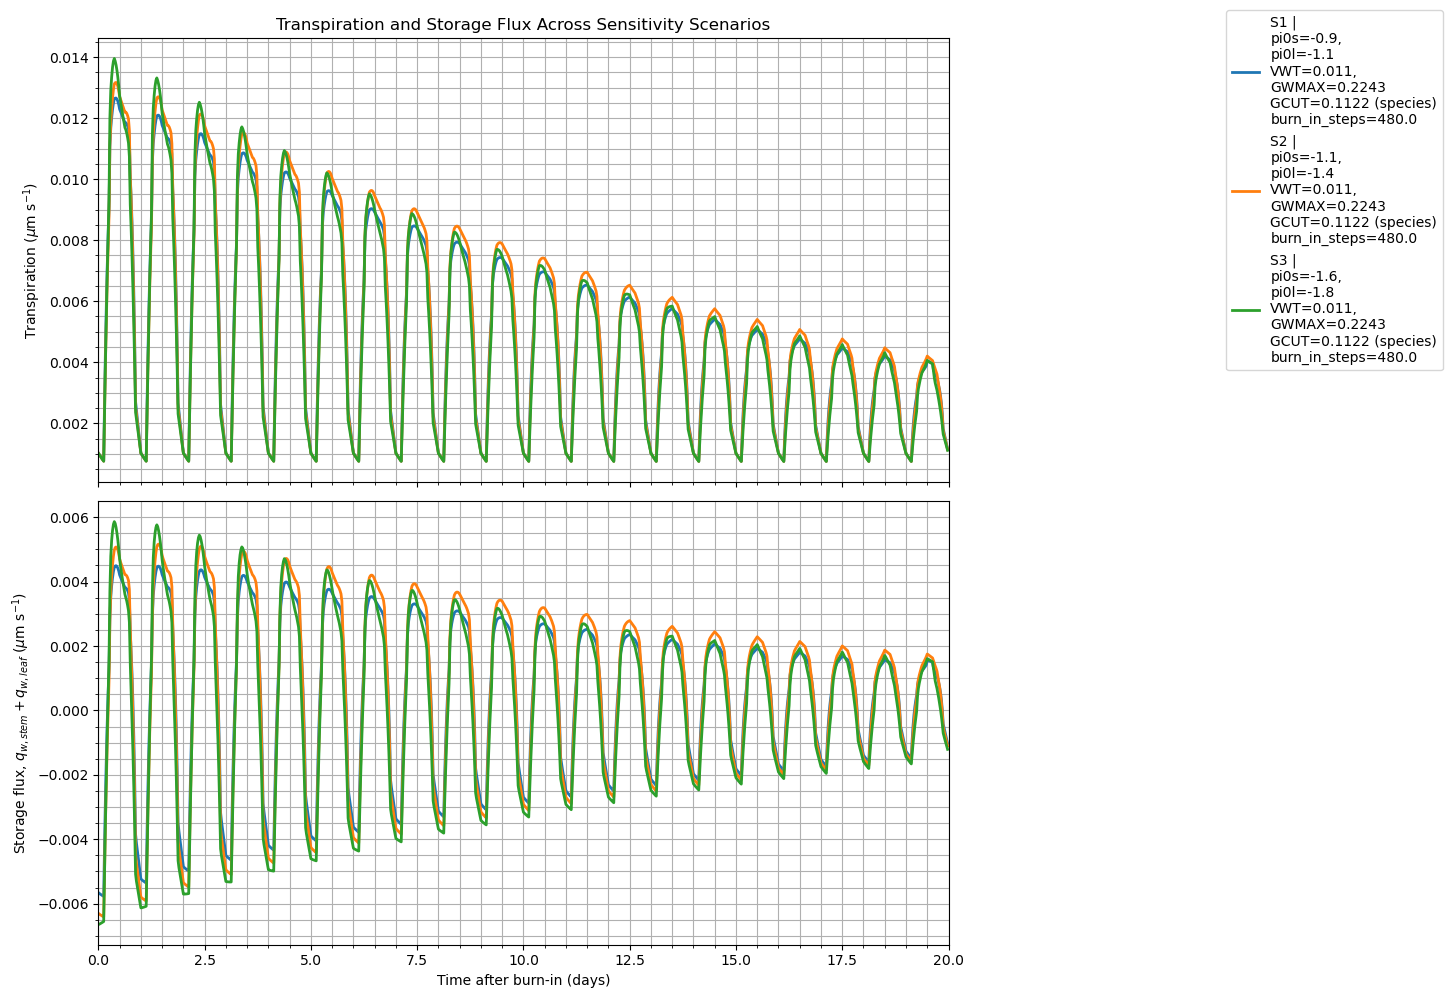

In [20]:
expected_steps = int(duration * 24 * 60 / timestepM)
candidate_lengths = []
for cfg in scenario_configs:
    out = results_by_scenario[cfg['name']]["output"]
    candidate_lengths.extend([len(out["ev"]), len(out["qw_stem"]), len(out["qw_leaf"])])
n_plot = min(candidate_lengths)
if n_plot != expected_steps:
    print(f"Warning: plotting {n_plot} steps, expected {expected_steps} from duration/timestep.")

# Use the maximum burn-in across scenarios so all series share the same time axis
max_burn_in = max(results_by_scenario[cfg["name"]]["burn_in_steps"] for cfg in scenario_configs)
post_burn_steps = n_plot - max_burn_in
post_burn_duration = post_burn_steps * dt / 86400.0  # days

time_plot = np.linspace(0.0, post_burn_duration, num=post_burn_steps, endpoint=False)
scenario_colors = {
    cfg["name"]: plt.cm.tab10(i % 10)
    for i, cfg in enumerate(scenario_configs)
}

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
ax_top, ax_bottom = axes

for cfg in scenario_configs:
    name = cfg["name"]
    label = results_by_scenario[name]["label"]
    out = results_by_scenario[name]["output"]
    color = scenario_colors[name]

    ev = np.array(out["ev"])[max_burn_in:n_plot]
    qw_stem = np.array(out["qw_stem"])[max_burn_in:n_plot]
    qw_leaf = np.array(out["qw_leaf"])[max_burn_in:n_plot]
    q_storage_sum = qw_stem + qw_leaf

    ax_top.plot(time_plot, ev, linewidth=2, color=color, label=label)
    ax_bottom.plot(time_plot, q_storage_sum, linewidth=2, color=color, label=label)

ax_top.set_title("Transpiration and Storage Flux Across Sensitivity Scenarios")
ax_top.set_ylabel(r"Transpiration ($\mu$m s$^{-1}$)")
ax_bottom.set_ylabel(r"Storage flux, $q_{w,stem}+q_{w,leaf}$ ($\mu$m s$^{-1}$)")
ax_bottom.set_xlabel("Time after burn-in (days)")

for ax in axes:
    ax.set_xlim(0, post_burn_duration)
    ax.minorticks_on()
    ax.grid(visible=True, which="both", axis="both")

handles, labels = ax_top.get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout(rect=[0, 0, 0.82, 1])
fig.savefig(run_output_dir / "transpiration_storage_flux.png", dpi=300, bbox_inches="tight")
plt.show()

## Plot: Potentials by Scenario

In [1]:
expected_steps = int(duration * 24 * 60 / timestepM)
candidate_lengths = []
for cfg in scenario_configs:
    out = results_by_scenario[cfg['name']]["output"]
    candidate_lengths.extend([len(out["psi_l"]), len(out["psi_w_stem"]), len(out["psi_w_leaf"]), len(out["psi_w_turgor_leaf"])])
n_plot = min(candidate_lengths)

# Use the maximum burn-in across scenarios so all series share the same time axis
max_burn_in = max(results_by_scenario[cfg["name"]]["burn_in_steps"] for cfg in scenario_configs)
post_burn_steps = n_plot - max_burn_in
post_burn_duration = post_burn_steps * dt / 86400.0  # days

time_plot = np.linspace(0.0, post_burn_duration, num=post_burn_steps, endpoint=False)
scenario_colors = {
    cfg["name"]: plt.cm.tab10(i % 10)
    for i, cfg in enumerate(scenario_configs)
}

fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)
series_specs = [
    ("psi_l", "Leaf water potential, psi_l (MPa)"),
    ("psi_w_stem", "Stem storage potential, psi_w_stem (MPa)"),
    ("psi_w_leaf", "Leaf storage potential, psi_w_leaf (MPa)"),
    ("psi_w_turgor_leaf", "Leaf turgor pressure, psi_w_turgor_leaf (MPa)"),
]

for ax, (key, ylabel) in zip(axes, series_specs):
    for cfg in scenario_configs:
        name = cfg["name"]
        label = results_by_scenario[name]["label"]
        y = np.array(results_by_scenario[name]["output"][key])[max_burn_in:n_plot]
        ax.plot(time_plot, y, linewidth=2, color=scenario_colors[name], label=label)
    ax.set_ylabel(ylabel)
    ax.minorticks_on()
    ax.grid(visible=True, which="both", axis="both")

axes[0].set_title("Potential Comparison Across Sensitivity Scenarios")
axes[-1].set_xlabel("Time after burn-in (days)")
axes[-1].set_xlim(0, post_burn_duration)
axes[0].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
fig.savefig(run_output_dir / "potentials_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

NameError: name 'duration' is not defined

## Plot: Soil Moisture Flux by Scenario


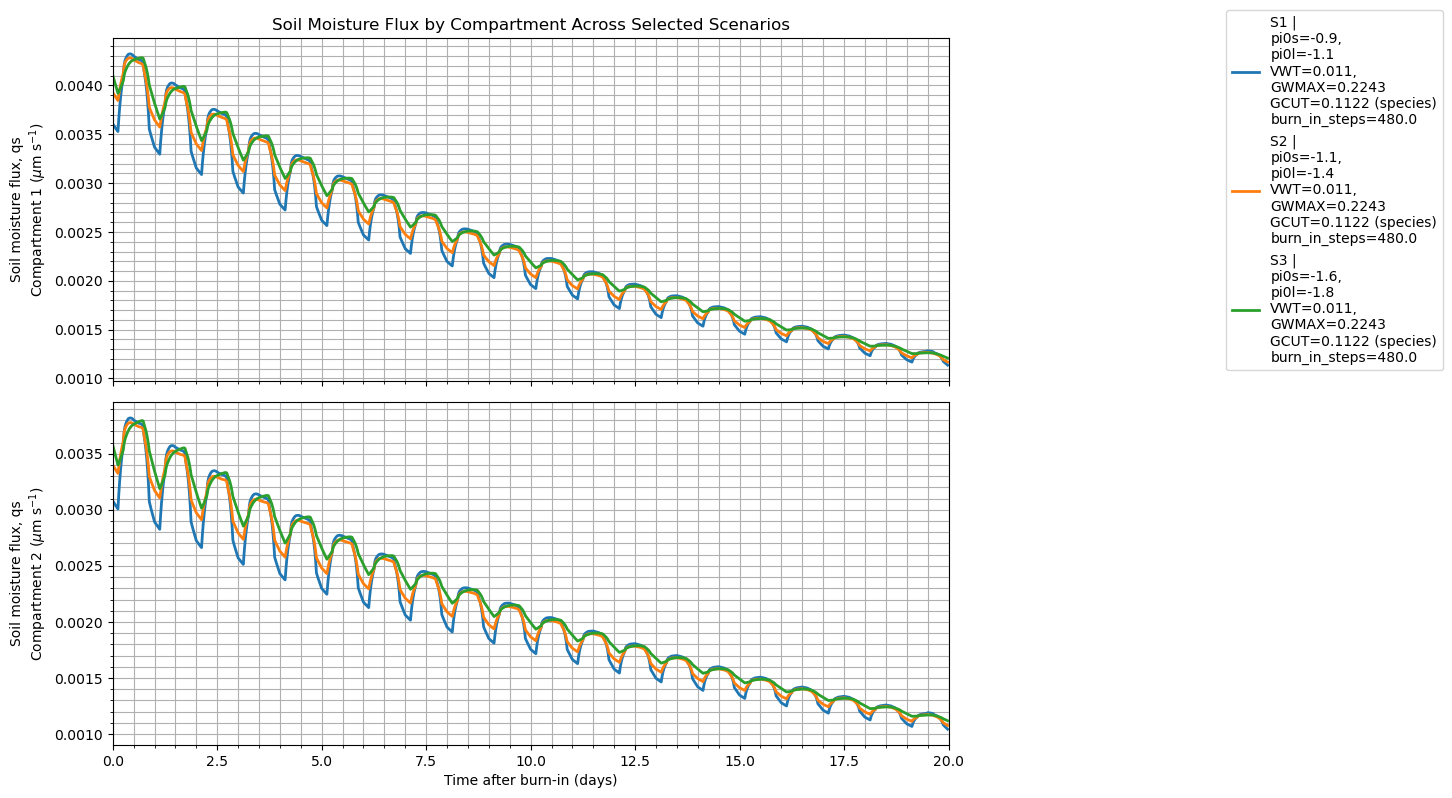

In [22]:
# Select which scenarios to plot (default = all)
scenarios_to_plot = [cfg["name"] for cfg in scenario_configs]
# To restrict, replace the line above with e.g.:
#   scenarios_to_plot = ["S1", "S3"]

candidate_lengths = []
for name in scenarios_to_plot:
    out = results_by_scenario[name]["output"]
    qs = out["qs"]
    for comp_series in qs:
        candidate_lengths.append(len(comp_series))
n_plot = min(candidate_lengths)

max_burn_in = max(results_by_scenario[cfg["name"]]["burn_in_steps"] for cfg in scenario_configs)
post_burn_steps = n_plot - max_burn_in
post_burn_duration = post_burn_steps * dt / 86400.0  # days

time_plot = np.linspace(0.0, post_burn_duration, num=post_burn_steps, endpoint=False)

# One subplot per soil compartment
n_comps = len(results_by_scenario[scenarios_to_plot[0]]["output"]["qs"])
fig, axes = plt.subplots(n_comps, 1, figsize=(12, 4 * n_comps), sharex=True)
if n_comps == 1:
    axes = [axes]

scenario_colors = {
    name: plt.cm.tab10(i % 10)
    for i, name in enumerate(scenarios_to_plot)
}

for comp_idx, ax in enumerate(axes):
    for name in scenarios_to_plot:
        label = results_by_scenario[name]["label"]
        qs_comp = np.array(results_by_scenario[name]["output"]["qs"][comp_idx])[max_burn_in:n_plot]
        ax.plot(time_plot, qs_comp, linewidth=2, color=scenario_colors[name], label=label)
    ax.set_ylabel(f"Soil moisture flux, qs\nCompartment {comp_idx + 1} ($\\mu$m s$^{{-1}}$)")
    ax.minorticks_on()
    ax.grid(visible=True, which="both", axis="both")

axes[0].set_title("Soil Moisture Flux by Compartment Across Selected Scenarios")
axes[-1].set_xlabel("Time after burn-in (days)")
axes[-1].set_xlim(0, post_burn_duration)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout(rect=[0, 0, 0.82, 1])
fig.savefig(run_output_dir / "soil_moisture_flux.png", dpi=300, bbox_inches="tight")
plt.show()

## Plot: Stem and Leaf Water Content by Scenario

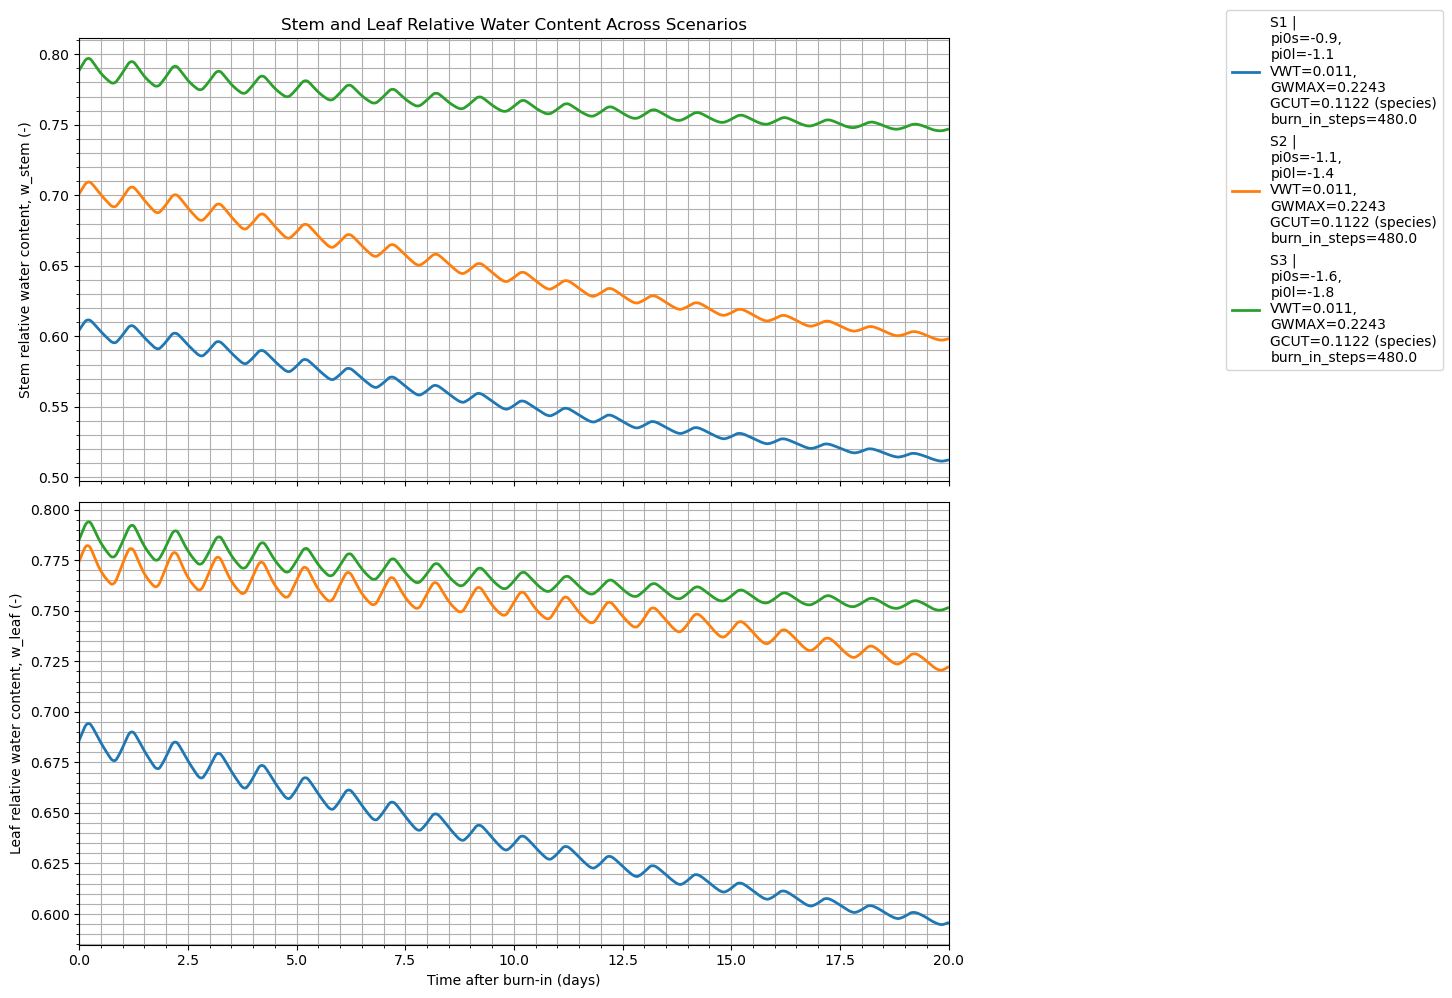

In [23]:
# Plot stem and leaf relative water content for all scenarios (post-burn-in only)
candidate_lengths = []
for cfg in scenario_configs:
    out = results_by_scenario[cfg["name"]]["output"]
    candidate_lengths.extend([len(out["w_stem"]), len(out["w_leaf"])])
n_plot = min(candidate_lengths)

max_burn_in = max(results_by_scenario[cfg["name"]]["burn_in_steps"] for cfg in scenario_configs)
post_burn_steps = n_plot - max_burn_in
post_burn_duration = post_burn_steps * dt / 86400.0  # days

time_plot = np.linspace(0.0, post_burn_duration, num=post_burn_steps, endpoint=False)
scenario_colors = {
    cfg["name"]: plt.cm.tab10(i % 10)
    for i, cfg in enumerate(scenario_configs)
}

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
ax_stem, ax_leaf = axes

for cfg in scenario_configs:
    name = cfg["name"]
    label = results_by_scenario[name]["label"]
    out = results_by_scenario[name]["output"]
    color = scenario_colors[name]

    w_stem = np.array(out["w_stem"])[max_burn_in:n_plot]
    w_leaf = np.array(out["w_leaf"])[max_burn_in:n_plot]

    ax_stem.plot(time_plot, w_stem, linewidth=2, color=color, label=label)
    ax_leaf.plot(time_plot, w_leaf, linewidth=2, color=color, label=label)

ax_stem.set_title("Stem and Leaf Relative Water Content Across Scenarios")
ax_stem.set_ylabel("Stem relative water content, w_stem (-)")
ax_leaf.set_ylabel("Leaf relative water content, w_leaf (-)")
ax_leaf.set_xlabel("Time after burn-in (days)")

for ax in axes:
    ax.set_xlim(0, post_burn_duration)
    ax.minorticks_on()
    ax.grid(visible=True, which="both", axis="both")

handles, labels = ax_stem.get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout(rect=[0, 0, 0.82, 1])
fig.savefig(run_output_dir / "stem_leaf_water_content.png", dpi=300, bbox_inches="tight")
plt.show()

## Plot: Stomatal Conductance by Scenario

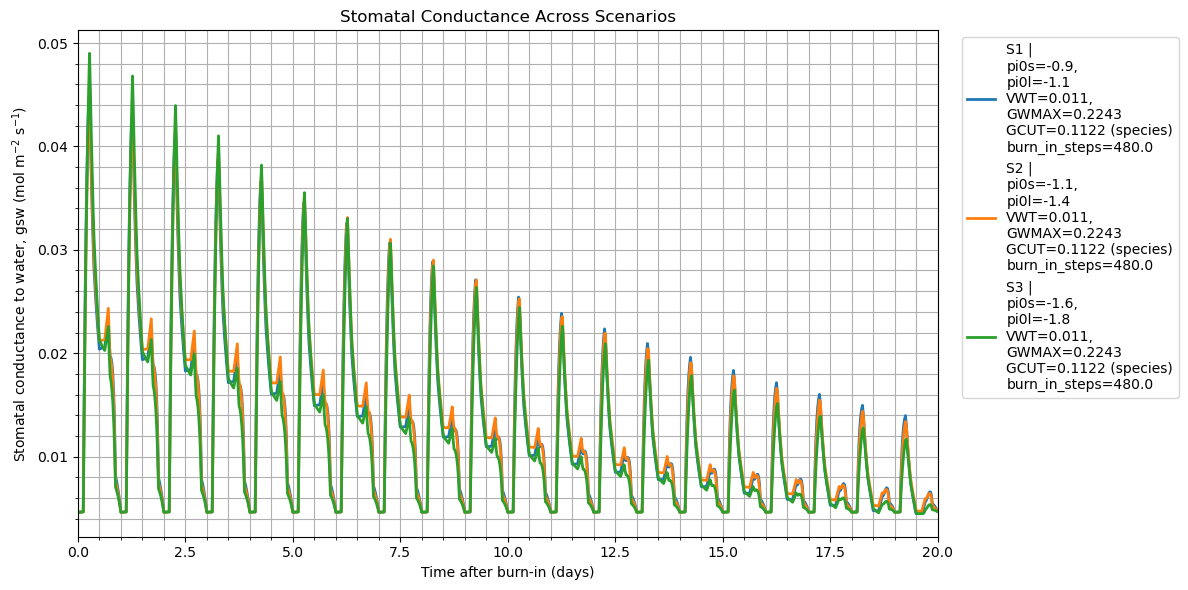

In [24]:
# Plot stomatal conductance (gsw) for all scenarios (post-burn-in only)
candidate_lengths = []
for cfg in scenario_configs:
    out = results_by_scenario[cfg["name"]]["output"]
    candidate_lengths.append(len(out["gsw"]))

n_plot = min(candidate_lengths)
max_burn_in = max(results_by_scenario[cfg["name"]]["burn_in_steps"] for cfg in scenario_configs)
post_burn_steps = n_plot - max_burn_in
post_burn_duration = post_burn_steps * dt / 86400.0  # days

time_plot = np.linspace(0.0, post_burn_duration, num=post_burn_steps, endpoint=False)
scenario_colors = {
    cfg["name"]: plt.cm.tab10(i % 10)
    for i, cfg in enumerate(scenario_configs)
}

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

for cfg in scenario_configs:
    name = cfg["name"]
    label = results_by_scenario[name]["label"]
    out = results_by_scenario[name]["output"]
    gsw = np.array(out["gsw"])[max_burn_in:n_plot]
    ax.plot(time_plot, gsw, linewidth=2, color=scenario_colors[name], label=label)

ax.set_title("Stomatal Conductance Across Scenarios")
ax.set_xlabel("Time after burn-in (days)")
ax.set_ylabel("Stomatal conductance to water, gsw (mol m$^{-2}$ s$^{-1}$)")
ax.set_xlim(0, post_burn_duration)
ax.minorticks_on()
ax.grid(visible=True, which="both", axis="both")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
fig.savefig(run_output_dir / "stomatal_conductance.png", dpi=300, bbox_inches="tight")
plt.show()

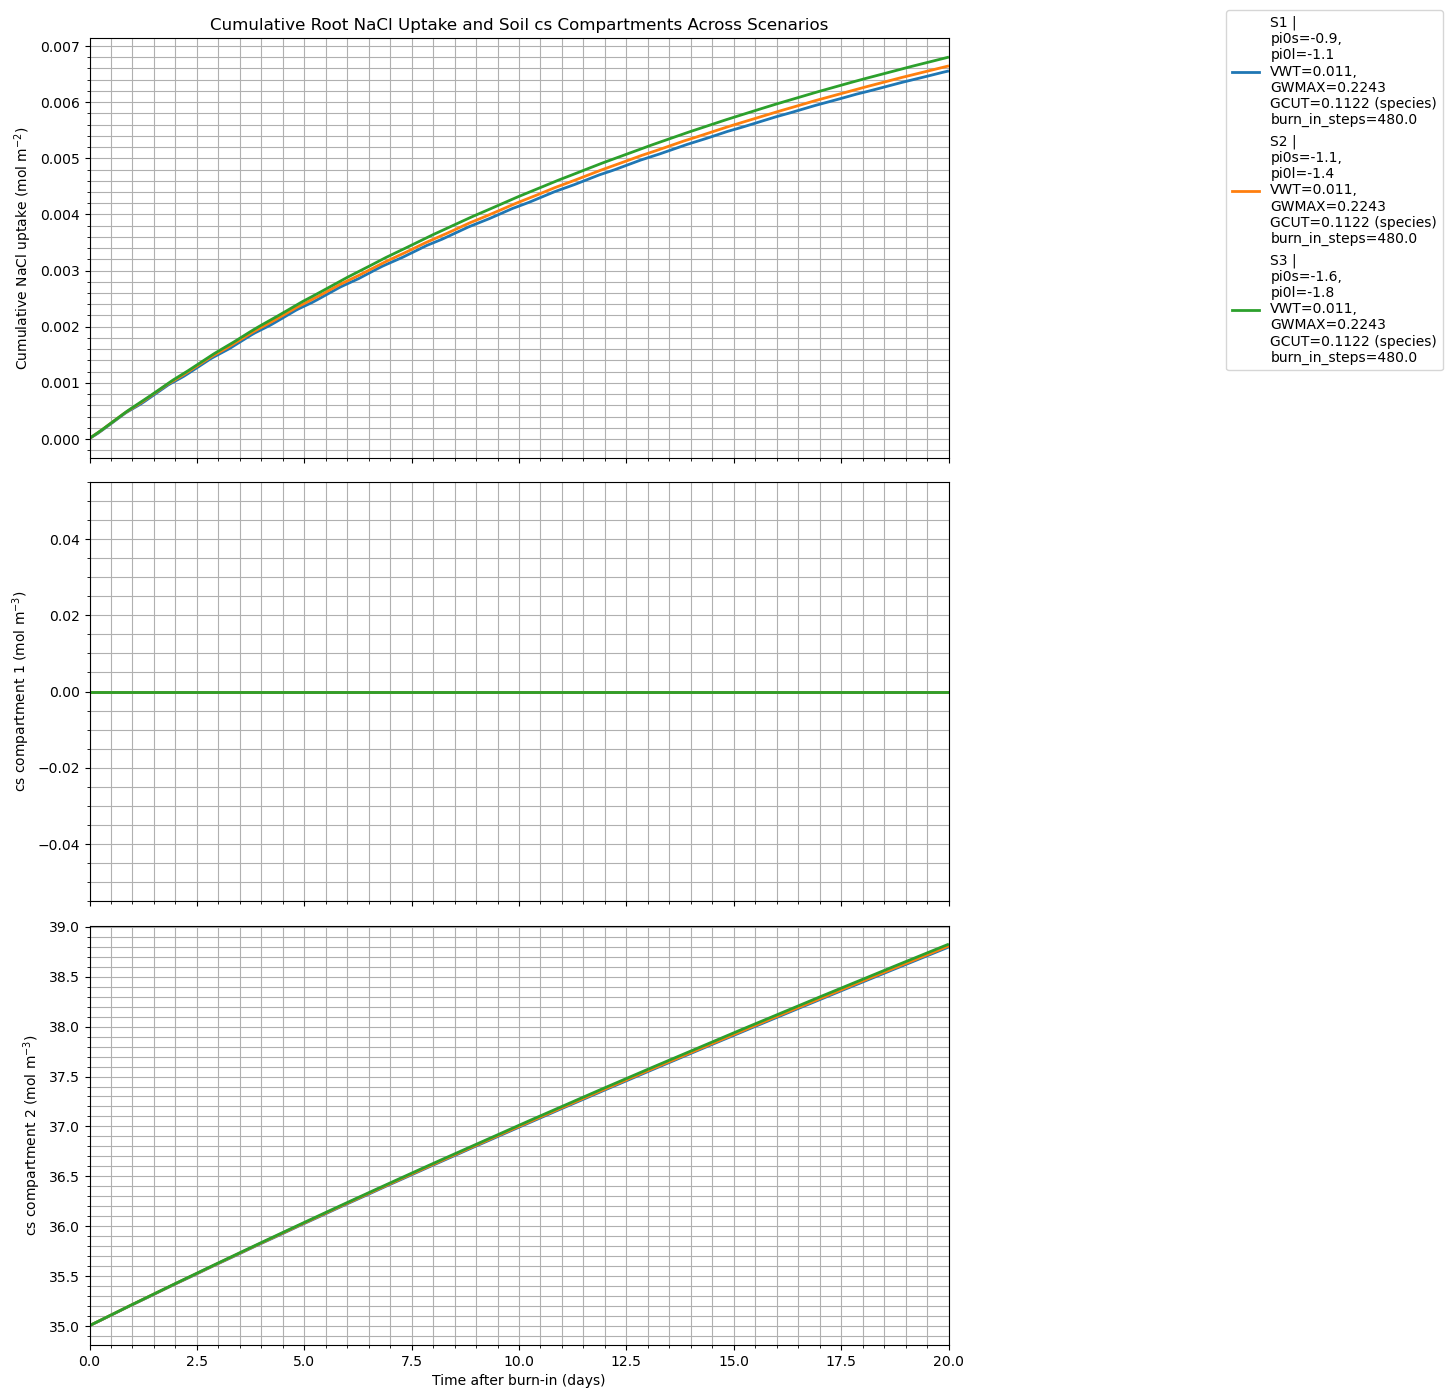

1800.0
[(array([0.00410497, 0.00407369, 0.00404266, 0.00401179, 0.00398108,
       0.00395053, 0.00392015, 0.00393604, 0.00395492, 0.00397566,
       0.00399775, 0.00402075, 0.00404428, 0.00409979, 0.00413536,
       0.00415896, 0.00417898, 0.00419699, 0.00421293, 0.00422561,
       0.0042361 , 0.00424487, 0.00425181, 0.00425676, 0.00425958,
       0.00426314, 0.00426677, 0.0042699 , 0.00427253, 0.00427468,
       0.00427636, 0.00427904, 0.00428119, 0.00428215, 0.00428188,
       0.00427622, 0.00424577, 0.0042193 , 0.00419052, 0.00415561,
       0.00411335, 0.00406253, 0.00400185, 0.00397095, 0.00394101,
       0.00391065, 0.00387988, 0.00384873, 0.00381724, 0.00378984,
       0.00376264, 0.00373557, 0.00370862, 0.0036818 , 0.0036551 ,
       0.00366976, 0.00368707, 0.003706  , 0.00372611, 0.00374701,
       0.00376835, 0.00381869, 0.00385077, 0.00387212, 0.00389032,
       0.00390672, 0.00392127, 0.00393283, 0.00394246, 0.00395057,
       0.00395707, 0.00396183, 0.00396474, 0.00396822

In [40]:
# Plot cumulative NaCl uptake with soil cs compartment subplots below (post-burn-in only)
# qs has units of um s^-1 and cs has units of mol m^-3.
# Conversion/integration per timestep: (qs * cs) * 1e-6 * dt => mol m^-2 per timestep.
# Multiply by LAI to scale by canopy leaf area index.

# Filtration efficiency
fe = 0.95

candidate_lengths = []
for cfg in scenario_configs:
    out = results_by_scenario[cfg["name"]]["output"]
    qs = out["qs"]
    cs = out["cs"]
    for qs_comp, cs_comp in zip(qs, cs):
        candidate_lengths.extend([len(qs_comp), len(cs_comp)])

n_plot = min(candidate_lengths)
max_burn_in = max(results_by_scenario[cfg["name"]]["burn_in_steps"] for cfg in scenario_configs)
post_burn_steps = n_plot - max_burn_in
post_burn_duration = post_burn_steps * dt / 86400.0  # days

time_plot = np.linspace(0.0, post_burn_duration, num=post_burn_steps, endpoint=False)
scenario_colors = {
    cfg["name"]: plt.cm.tab10(i % 10)
    for i, cfg in enumerate(scenario_configs)
}

# Scenario-specific LAI from the built scenario objects
lai_by_scenario = {run["config"]["name"]: float(run["species"].LAI) for run in scenario_runs}

fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=True)
ax_uptake, ax_cs1, ax_cs2 = axes

for cfg in scenario_configs:
    name = cfg["name"]
    label = results_by_scenario[name]["label"]
    out = results_by_scenario[name]["output"]
    lai = lai_by_scenario[name]

    qs_post = [np.array(comp)[max_burn_in:n_plot] for comp in out["qs"]]
    cs_post = [np.array(comp)[max_burn_in:n_plot] for comp in out["cs"]]

    summed_products = np.sum([
        qs_comp * cs_comp
        for qs_comp, cs_comp in zip(qs_post, cs_post)
    ], axis=0)

    moles_per_timestep = summed_products * 1e-6 * dt * lai * (1 - fe)
    cumulative_moles = np.cumsum(moles_per_timestep)

    cs_comp1_post = np.array(out["cs"][0])[max_burn_in:n_plot]
    cs_comp2_post = np.array(out["cs"][1])[max_burn_in:n_plot]

    ax_uptake.plot(
        time_plot,
        cumulative_moles,
        linewidth=2,
        color=scenario_colors[name],
        label=label,
    )
    ax_cs1.plot(time_plot, cs_comp1_post, linewidth=2, color=scenario_colors[name], label=label)
    ax_cs2.plot(time_plot, cs_comp2_post, linewidth=2, color=scenario_colors[name], label=label)

ax_uptake.set_title("Cumulative Root NaCl Uptake and Soil cs Compartments Across Scenarios")
ax_uptake.set_ylabel(r"Cumulative NaCl uptake ($\mathrm{mol\ m^{-2}}$)")
ax_cs1.set_ylabel("cs compartment 1 (mol m$^{-3}$)")
ax_cs2.set_ylabel("cs compartment 2 (mol m$^{-3}$)")
ax_cs2.set_xlabel("Time after burn-in (days)")

for ax in axes:
    ax.set_xlim(0, post_burn_duration)
    ax.minorticks_on()
    ax.grid(visible=True, which="both", axis="both")

handles, labels = ax_uptake.get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout(rect=[0, 0, 0.82, 1])
fig.savefig(run_output_dir / "cumulative_nacl_uptake_with_cs_compartments.png", dpi=300, bbox_inches="tight")
plt.show()

print(dt)
print(list(zip(qs_post, cs_post)))